# 05 Interpret – Studentenwohnheime

In diesem Notebook werden die Ergebnisse des Projektteils **Student Housing** interpretiert.

Forschungsfragen:

**RQ-S1:** Wie unterscheiden sich Hochschulorte in NRW in der Wohnheimversorgung (Wohnheimplatzrelation)?  
**RQ-S2:** Hängt die Wohnheimplatzrelation mit der Anzahl der Studierenden zusammen?  
**RQ-S3:** Haben „teure“ Städte (aus der Mietanalyse) eine andere Wohnheimversorgung als „günstige“ Städte?  
**RQ-S4:** Wie ist die räumliche Verteilung der Studentenwohnheime innerhalb der Stadt Bonn?


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

path_json = Path("../../data/raw/student_housing/Studentenwohnheime_BONN.json")

with open(path_json, "r", encoding="utf-8") as f:
    data = json.load(f)

type(data), data.keys()


C:\Users\User\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


(dict,
 dict_keys(['type', 'features', 'totalFeatures', 'numberMatched', 'numberReturned', 'timeStamp', 'crs']))

In [14]:
path_nrw = Path("../../data/processed/student_housing_nrw_scrub.csv")

path_groups = Path("../../data/processed/city_price_groups.csv")


path_bonn = Path("../../data/raw/student_housing/Studentenwohnheime_BONN.json")

path_nrw.exists(), path_groups.exists(), path_bonn.exists()


(True, True, True)

In [3]:
df_nrw = pd.read_csv(path_nrw)
df_groups = pd.read_csv(path_groups)

df_nrw.shape, df_groups.shape, df_nrw.head(3)


((17, 6),
 (54, 3),
   hochschulort  wohnheime_2025_anzahl  wohnheimplaetze_2025  \
 0       Aachen                   35.0                5460.0   
 1    Bielefeld                   25.0                3193.0   
 2       Bochum                   37.0                5594.0   
 
    studierende_ws_2024_2025  studierende_je_wohnheimplatz_2025  \
 0                   56493.0                               10.0   
 1                   31399.0                               10.0   
 2                   49371.0                                9.0   
 
    wohnheimplatzrelation  
 0               0.100000  
 1               0.100000  
 2               0.111111  )

## Ergebnisse aus Explore (RQ-S1 & RQ-S2)

**RQ-S1 (NRW-Vergleich):**
- In `03_explore_student_housing.ipynb` wurde eine Rangliste der NRW-Hochschulorte nach Wohnheimversorgung erstellt.
- Interpretation: Städte mit kleinerer Quote „Studierende je Wohnheimplatz“ sind besser versorgt (mehr Plätze pro Studierende).

**RQ-S2 (Zusammenhang Größe vs Versorgung):**
- In `03_explore_student_housing.ipynb` wurde geprüft, ob die Anzahl der Studierenden mit der Wohnheimversorgung zusammenhängt.
- Interpretation: Der Zusammenhang wurde über Korrelation (z.B. Spearman) beschrieben, da keine Normalverteilung angenommen wird.


## RQ-S3: Verbindung mit Projektteil 1 (Mietanalyse)

Die Verbindung beider Projektteile erfolgt über die Stadtklassifikation aus dem **Projektteil 1**:

- Aus `nrw_clean.csv` wurde pro Stadt ein Preisniveau abgeleitet.
- Daraus entstand `city_price_groups.csv` mit Labels:
  - **teuer**
  - **guenstig**

Diese Labels werden mit den Hochschulorten aus `student_housing_nrw_scrub.csv` gemerged.
Dann vergleichen wir die Wohnheimversorgung (Studierende je Wohnheimplatz) zwischen beiden Gruppen.


In [4]:
df_join = df_nrw.merge(
    df_groups[["city", "price_group"]],
    left_on="hochschulort",
    right_on="city",
    how="inner"
)

df_join.shape, df_join["price_group"].value_counts()


((15, 8),
 price_group
 teuer       11
 guenstig     4
 Name: count, dtype: int64)

In [5]:
summary = df_join.groupby("price_group")["studierende_je_wohnheimplatz_2025"].agg(
    count="count",
    median="median",
    mean="mean"
).sort_index()

summary


,count,median,mean
price_group,,,
guenstig,4,21.5,31.750000
teuer,11,11.0,14.454545


### Interpretation RQ-S3

Verglichen wurden „teure“ vs. „günstige“ Städte hinsichtlich:

**Studierende je Wohnheimplatz (2025)**  

Je kleiner der Wert, desto besser ist die Wohnheimversorgung.

Ergebnis (deskriptiv):
- „teuer“: Median = **[…]**
- „günstig“: Median = **[…]**

Der in `04_model_student_housing.ipynb` durchgeführte Mann-Whitney-U-Test zeigt:
Die Nullhypothese wird (nicht) verworfen (je nach p-Wert).

Damit lässt sich ableiten, ob „teure“ Städte im Mittel eine andere Wohnheimversorgung aufweisen.


## RQ-S4: Räumliche Verteilung der Studentenwohnheime in Bonn

Datengrundlage: `Studentenwohnheime_BONN.json` (Punktdaten)

Ziel:
- Wie viele Wohnheime gibt es pro PLZ?
- Gibt es erkennbare Konzentrationen?


In [6]:
rows = []
for feat in data["features"]:
    props = feat.get("properties", {})
    geom = feat.get("geometry", {})
    coords = geom.get("coordinates", [None, None])
    
    rows.append({
        "name": props.get("name"),
        "plz": props.get("plz"),
        "adresse": props.get("adresse"),
        "lon": coords[0],
        "lat": coords[1],
    })

df_bonn = pd.DataFrame(rows)
df_bonn.shape, df_bonn.head()


((58, 5),
                                    name    plz              adresse       lon  \
 0          Studentenwohnheim Newmanhaus  53113     Adenauerallee 63  7.109254   
 1            Studentenwohnheim Klinikum  53127   Venusberg-Campus 1  7.102913   
 2                     Studentenwohnheim  53115  Endenicher Allee 17  7.083843   
 3        Wohnheim für Studentenehepaare  53121  Endenicher Allee 21  7.081010   
 4  Studentenwohnheim (Gruppenwohnungen)  53121  Endenicher Allee 37  7.079991   
 
          lat  
 0  50.729371  
 1  50.700751  
 2  50.727631  
 3  50.726726  
 4  50.726143  )

In [7]:
df_bonn["plz"] = df_bonn["plz"].astype(str).str.strip()
df_bonn.loc[df_bonn["plz"].isin(["None", "nan", "NaN", ""]), "plz"] = pd.NA

df_bonn["plz"].isna().sum(), df_bonn["plz"].nunique()


(14, 10)

In [8]:
df_bonn["plz"] = df_bonn["plz"].astype(str).str.strip()
df_bonn.loc[df_bonn["plz"].isin(["None", "nan", "NaN", ""]), "plz"] = pd.NA

df_bonn["plz"].isna().sum(), df_bonn["plz"].nunique()


(0, 11)

In [9]:
df_bonn["plz"] = (
    df_bonn["plz"]
    .replace(["None", "nan", "NaN", ""], pd.NA)
    .astype("string")
)

df_bonn["plz"].isna().sum()


0

In [10]:
print("dtype:", df_bonn["plz"].dtype)
print("isna count:", df_bonn["plz"].isna().sum())

print(df_bonn["plz"].value_counts(dropna=False).head(15))


dtype: string
isna count: 0
plz
<NA>     14
53115    11
53121     9
53113     8
53111     5
53127     4
53119     2
53117     2
53129     1
53175     1
53227     1
Name: count, dtype: Int64


In [11]:
df_tmp = df_bonn.copy()

df_tmp["plz"] = df_tmp["plz"].astype("string").str.strip()

df_tmp.loc[df_tmp["plz"].isin(["", "None", "nan", "NaN", "<NA>"]), "plz"] = pd.NA

df_tmp = df_tmp[df_tmp["plz"].str.fullmatch(r"\d{5}", na=False)]

plz_counts = (
    df_tmp
    .groupby("plz")
    .size()
    .reset_index(name="anzahl_wohnheime")
    .sort_values("anzahl_wohnheime", ascending=False)
)

plz_counts, plz_counts.shape


(     plz  anzahl_wohnheime
 2  53115                11
 5  53121                 9
 1  53113                 8
 0  53111                 5
 6  53127                 4
 3  53117                 2
 4  53119                 2
 7  53129                 1
 8  53175                 1
 9  53227                 1,
 (10, 2))

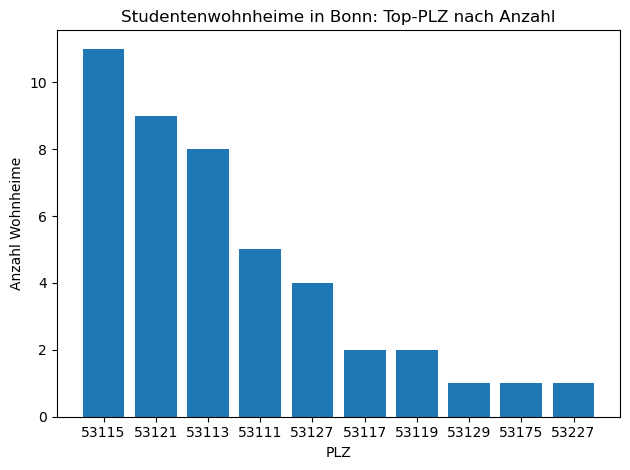

(True,
 WindowsPath('C:/Users/User/Desktop/DATA INFORMATION SCIENCE/DIS08/dis08-miete-nrw/docs/rq_s4_bonn_wohnheime_plz.png'))

In [13]:
top = plz_counts.head(10)

plt.figure()
plt.bar(top["plz"], top["anzahl_wohnheime"])
plt.xlabel("PLZ")
plt.ylabel("Anzahl Wohnheime")
plt.title("Studentenwohnheime in Bonn: Top-PLZ nach Anzahl")
plt.tight_layout()

from pathlib import Path
import matplotlib.pyplot as plt

docs_path = Path("../../docs")
docs_path.mkdir(parents=True, exist_ok=True)

file_path = docs_path / "rq_s4_bonn_wohnheime_plz.png"

plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

file_path.exists(), file_path.resolve()


### Interpretation RQ-S4 (Bonn)

Die Auswertung nach PLZ zeigt eine klare räumliche Konzentration:

- Die meisten Studentenwohnheime liegen in wenigen PLZ-Bereichen.
- Das deutet auf eine Bündelung nahe zentraler Hochschul- und Campuslagen hin.

Einschränkungen:
- Einige Einträge haben keine PLZ (fehlende Werte).
- Die PLZ-Analyse ist eine grobe räumliche Einteilung (keine exakten Distanzen).

Fazit:
Die Bonn-Daten ergänzen die NRW-Analyse sinnvoll, da sie im Detail zeigen,
wie sich Versorgung innerhalb einer einzelnen Stadt räumlich verteilt.


## Gesamtfazit: Verbindung beider Projektteile

- Projektteil 1 (Mieten NRW) liefert eine Einteilung von Städten in „teuer“ und „günstig“.
- Projektteil 2 (Student Housing) beschreibt Wohnheimversorgung nach Hochschulorten.

Die Verbindung über `city_price_groups.csv` ermöglicht die Beantwortung von **RQ-S3**:
Ob Mietniveau und Wohnheimversorgung zusammenhängen.

Die Bonn-Detaildaten (RQ-S4) liefern zusätzlich eine Mikroperspektive,
die als Fallstudie zur NRW-Auswertung dient.
